In [36]:
from order_book import OrderBook
from models import Order, ReqType, Request, Trade
from agents import Trader
from simulation import Simulation
from strategies.naivemm import NaiveMM
from strategies.random_strat import Random

from analytics import Analytics

from collections import deque
from dataclasses import dataclass
from enum import Enum
import matplotlib as plt

In [37]:
sim = Simulation(initial_price=100)
analysis = Analytics(sim)

# create 100 random agents with fixed probabilities
for i in range(1, 11):
    strat = Random(
        buy_probability=0.33,
        sell_probability=0.33,
        cancel_probability=0.2,
        limit_probability=0.8,
        max_quantity=10,
        max_price_offset=10,
        reference_price=sim.initial_price,
    )
    agent = Trader(
        model=sim,
        agent_id=i,
        initial_cash=10000,
        initial_position=100,
        strategy=strat
    )
    sim.traders[i] = agent

strat = NaiveMM(
    half_spread=2,
    time_req=2,
    tolerance=2,
    quantity=10
)

sim.traders[11] = Trader(
    model=sim,
    agent_id=11,
    initial_cash=10000,
    initial_position=100,
    strategy=strat,
)

In [38]:
sim.run_sim(10000)
len(sim.book.trades)

35148

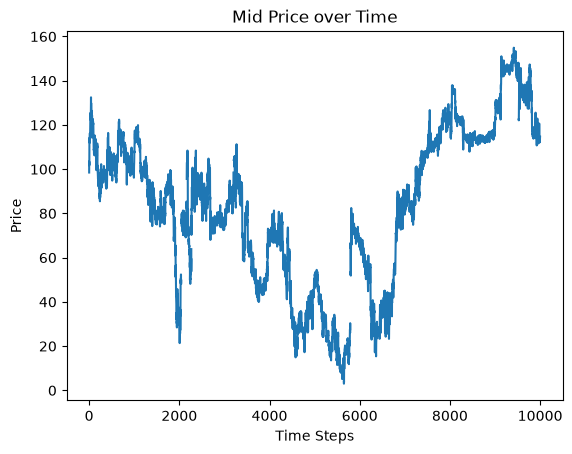

In [39]:
analysis.plot_midprice()

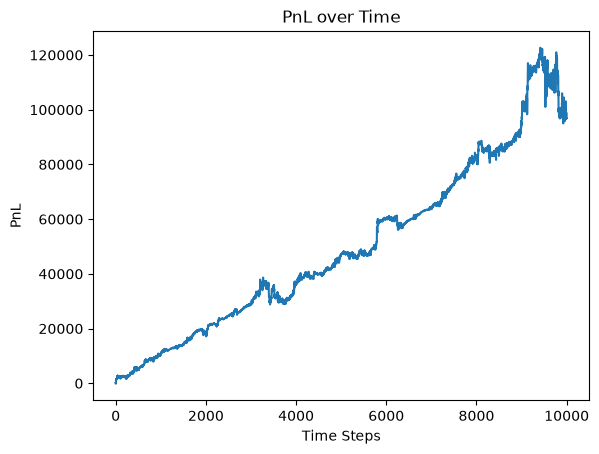

In [40]:
analysis.plot_agent_pnl(11)

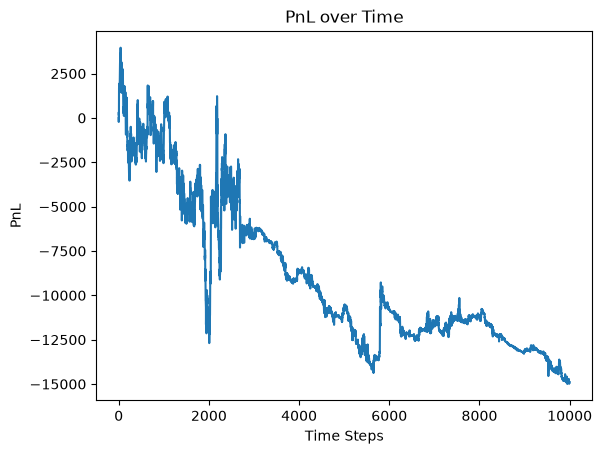

In [41]:
analysis.plot_agent_pnl(1)

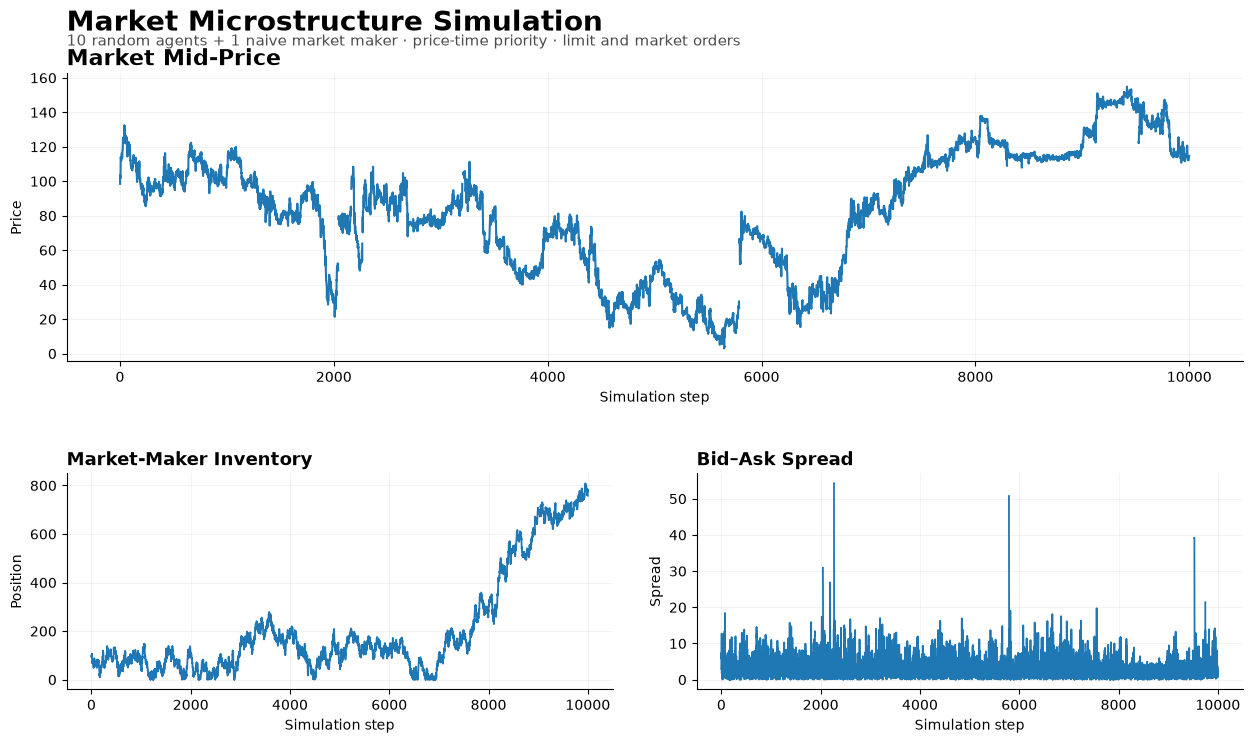

In [42]:


analysis.plot_portfolio_summary(
    sim,
    market_maker_id=11,
    save_path="portfolio_simulation.png"
)